# 12 · Capstone: an evidence-led climate story

**Time:** 60 minutes · **Audience:** undergraduate / introductory graduate GIS and Earth science.

**By the end:** Produce a reproducible map narrative that states uncertainty, provenance, and a responsible interpretation.

[Run in JupyterLite](https://jltobias.github.io/JupyterLite-zarr-sql-views/lite/lab/index.html?path=12_capstone.ipynb) · [Earth lab](https://jltobias.github.io/JupyterLite-zarr-sql-views/lab/) · [Sources and licenses](https://jltobias.github.io/JupyterLite-zarr-sql-views/book/credits.html)

Run cells from top to bottom with **Shift+Enter**. The first kernel start downloads Python WebAssembly packages.
The bundled exercises need no data-service account. Save a copy with **File → Save and Export Notebook As** before clearing browser storage.

![Four-stage workflow: STAC discovery, Zarr reading, SQL selection, linked views](assets/pipeline.svg)

In [1]:
from course import *
import numpy as np
import matplotlib.pyplot as plt
print('Ready: Python + NumPy + local teaching data')

Ready: Python + NumPy + local teaching data


## 1. Choose a question with a bounded claim

Choose observed Lake Ngami water change, C3S model-member spread, or a clearly labeled synthetic method experiment.
Frame a claim the available data can answer. For an African climate-burden discussion, pair the result with the IPCC Africa chapter
and local knowledge; neither the notebook nor an attractive map establishes impacts on its own.

(0, 2304, 0.05569330946390336)
(1, 2304, 0.005169411780823591)
(2, 2304, 0.00616129876531583)


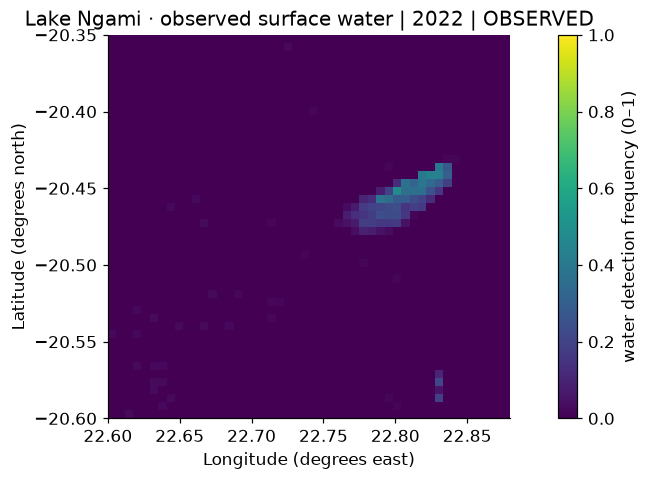

In [2]:
meta,values=load_cube('ngami')
con=sql_connection(meta,values)
result=list(con.execute('SELECT t, COUNT(value), AVG(value) FROM cells GROUP BY t ORDER BY t'))
for row in result: print(row)
map_slice(meta,values,2);plt.show()

## 2. Record your method as structured evidence

Fill this record with your own choices. Cite both upstream software and actual data used.
When sharing, include a screenshot or static figure, the notebook, a GeoJSON if relevant, and the record below.

In [3]:
record={
 'question':'How does sampled water detection differ across the three supplied years?',
 'dataset':meta['title'], 'origin':meta['kind'], 'units':meta['units'],
 'method':'Mean across available sampled cells; quality mask in provenance',
 'limitations':['Three snapshots cannot establish a climate trend','Sampled cells are not equal-area flood extent'],
 'next_evidence':['Longer water and rainfall record','Local hydrological interpretation'],
 'source':meta['source'], 'license':meta['license']
}
Path('evidence-record.json').write_text(json.dumps(record,indent=2),encoding='utf-8')
print(json.dumps(record,indent=2))

{
  "question": "How does sampled water detection differ across the three supplied years?",
  "dataset": "Lake Ngami \u00b7 observed surface water",
  "origin": "observed",
  "units": "water detection frequency (0\u20131)",
  "method": "Mean across available sampled cells; quality mask in provenance",
  "limitations": [
    "Three snapshots cannot establish a climate trend",
    "Sampled cells are not equal-area flood extent"
  ],
  "next_evidence": [
    "Longer water and rainfall record",
    "Local hydrological interpretation"
  ],
  "source": "Digital Earth Africa / Landsat",
  "license": "CC-BY-4.0"
}


## 3. Peer review with a 20-point rubric

| Criterion | Points | What to check |
|---|---:|---|
| Question and scope | 4 | Claim fits spatial and temporal support |
| Reproducibility | 4 | Code runs; transformations and filters are stated |
| Provenance | 4 | Data origin, version, license, and software credits |
| Visual reasoning | 4 | Units, scale, uncertainty, text alternative |
| Interpretation | 4 | Distinguishes observation, inference, and missing evidence |

Ask a peer to change a threshold or mask. Does your conclusion survive? If not, revise the claim instead of hiding the sensitivity.

## 4. Plan the next version

For a real climate-impact project: co-design the question with affected communities; select an appropriate observed or modeled product;
create a bounded, licensed subset; test coordinate and unit handling; validate against independent evidence; then communicate the uncertainty.
The digital method is only one part of that work.

## Try it yourself

Submit a notebook, evidence record, and a two-minute explanation of what the visualization cannot establish.

## Check your reasoning

A strong submission makes a modest, reproducible claim and identifies the next evidence needed. A synthetic exercise is valid when its data origin remains unmistakable.

## Evidence journal

Write four sentences: **what I observed; how I calculated it; what this cannot establish; what evidence I need next**.
For any figure you reuse, retain its units, date or scenario, data origin, transformations, and attribution.

## Sources and credit

- [zarr-sql-views, source architecture and ISC license](https://github.com/dzole0311/zarr-sql-views)
- [Digital Earth Africa WOfS specifications and limitations](https://docs.digitalearthafrica.org/en/latest/data_specs/Landsat_WOfS_specs.html), CC BY 4.0 data.
- [C3S Atlas user tools](https://github.com/ecmwf-projects/c3s-atlas), European Union, Apache 2.0; pinned auxiliary CMIP6 warming-level table.
- [IPCC AR6 WGII, Chapter 9: Africa](https://www.ipcc.ch/report/ar6/wg2/chapter/chapter-9/). Linked context, not redistributed data.

Teaching adaptation of [dzole0311/zarr-sql-views](https://github.com/dzole0311/zarr-sql-views), ISC.
Original teaching code and prose: JupyterLite-zarr-sql-views contributors, ISC. Data keep their separate licenses.